# Bayesian Posterior as Prior–Likelihood Fusion

Bayesian inference combines prior belief and data evidence through:
$$
p(\theta\mid y)\propto p(y\mid\theta)\,p(\theta).
$$
This notebook illustrates visually how posterior mode and spread move when we animate the prior.

The key stake is interpretability: understanding how uncertainty and bias are jointly controlled by model and prior.

Bayes' rule combines information multiplicatively,
$$p(\theta\mid y)=\frac{p(y\mid\theta)p(\theta)}{\int p(y\mid u)p(u)\,du}.$$
The central question is not only where the posterior mode lies, but how prior location and uncertainty reshape posterior mass. Static comparisons and posterior moments make that tradeoff explicit.


## Environment

We use a one-dimensional Gaussian likelihood/prior family for analytic transparency.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

plt.rcParams["figure.dpi"] = 120


## Grid and Gaussian helper

Define normalized densities on a fixed parameter grid.


In [2]:
t = np.linspace(-3, 7, 1500)

def gaussian_pdf(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)


## Baseline likelihood

Interpret this as data information independent of prior choice.


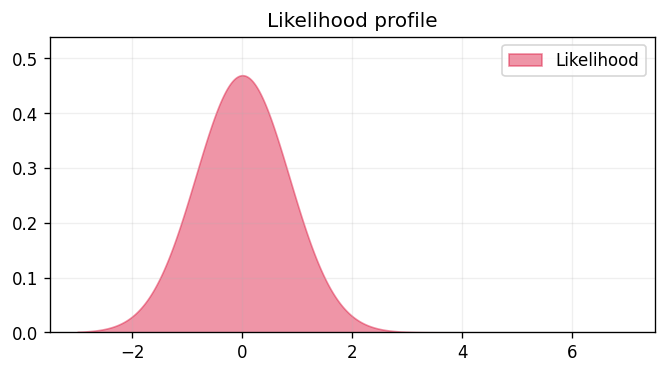

In [3]:
likelihood = gaussian_pdf(t, m=0.0, s=0.85)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.fill_between(t, likelihood, color="crimson", alpha=0.45, label="Likelihood")
ax.set_title("Likelihood profile")
ax.set_ylim(0, likelihood.max() * 1.15)
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## Posterior computation

Multiply and renormalize densities to obtain a valid posterior.


In [4]:
def posterior_from_prior(prior_mean, prior_std):
    prior = gaussian_pdf(t, m=prior_mean, s=prior_std)
    post = prior * likelihood
    post /= np.trapezoid(post, t)
    return prior, post


## Prior sensitivity at fixed likelihood

For a Gaussian likelihood $\mathcal N(m_\ell,\sigma_\ell^2)$ and prior
$\mathcal N(m_p,\sigma_p^2)$, the posterior is Gaussian with precision and mean

$$
\frac{1}{\sigma_{\mathrm{post}}^2}
=\frac{1}{\sigma_\ell^2}+\frac{1}{\sigma_p^2},
\qquad
m_{\mathrm{post}}
=\sigma_{\mathrm{post}}^2\left(
\frac{m_\ell}{\sigma_\ell^2}+\frac{m_p}{\sigma_p^2}
\right).
$$

The three panels hold the likelihood fixed and vary only the prior. A broad prior
leaves the data dominant; a concentrated prior pulls the posterior toward its mean.

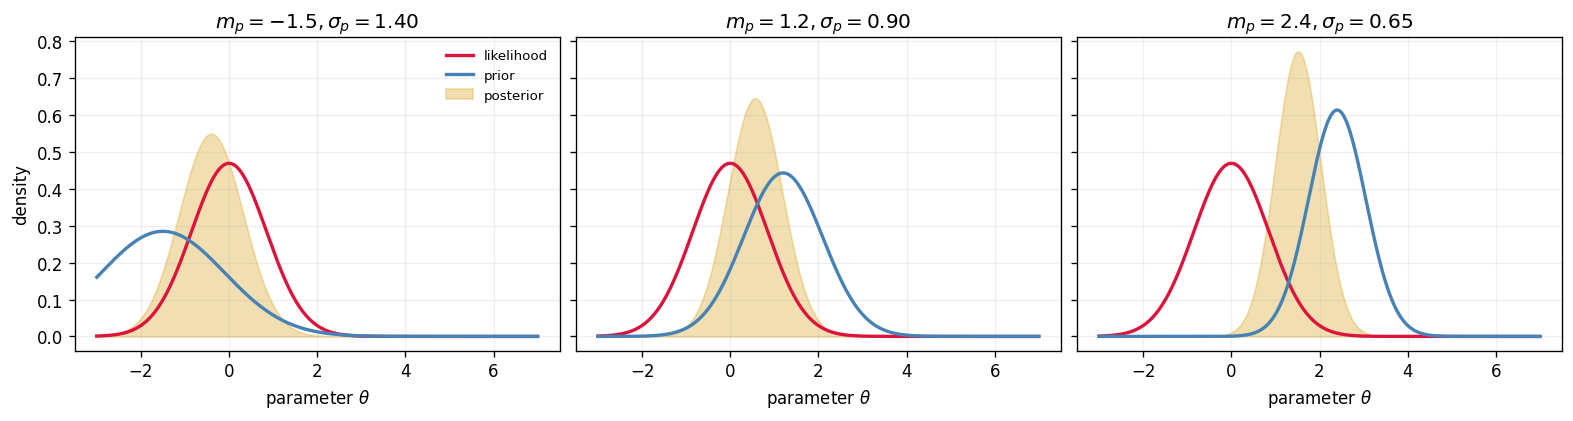

In [5]:
prior_settings = [(-1.5, 1.4), (1.2, 0.9), (2.4, 0.65)]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4), sharex=True, sharey=True,
                         constrained_layout=True)

for ax, (prior_mean, prior_std) in zip(axes, prior_settings):
    prior, post = posterior_from_prior(prior_mean, prior_std)
    ax.plot(t, likelihood, color="crimson", lw=2, label="likelihood")
    ax.plot(t, prior, color="steelblue", lw=2, label="prior")
    ax.fill_between(t, post, color="goldenrod", alpha=0.35, label="posterior")
    ax.set_title(fr"$m_p={prior_mean:.1f}, \sigma_p={prior_std:.2f}$")
    ax.set_xlabel(r"parameter $\theta$")
    ax.grid(alpha=0.2)

axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=8)
plt.show()

## Interactive prior influence

Observe how posterior mode interpolates prior mode and likelihood mode.


In [6]:
def explore_prior(prior_mean=1.2, prior_std=0.9):
    prior, post = posterior_from_prior(prior_mean, prior_std)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(t, likelihood, color="crimson", lw=2, label="likelihood")
    ax.plot(t, prior, color="steelblue", lw=2, label="prior")
    ax.fill_between(t, post, color="goldenrod", alpha=0.4, label="posterior")
    ax.set_xlabel(r"parameter $	heta$")
    ax.set_ylabel("density")
    ax.set_title("Prior-likelihood fusion")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.show()


interact(
    explore_prior,
    prior_mean=FloatSlider(min=-2.0, max=4.0, step=0.1, value=1.2,
                           description="prior mean"),
    prior_std=FloatSlider(min=0.3, max=2.0, step=0.05, value=0.9,
                          description="prior std"),
);

interactive(children=(FloatSlider(value=1.2, description='prior mean', max=4.0, min=-2.0), FloatSlider(value=0…

## Posterior moments

Compute posterior mean and variance numerically.


In [7]:
prior, post = posterior_from_prior(2.4, 0.65)
m_post = np.trapezoid(t * post, t)
v_post = np.trapezoid((t - m_post) ** 2 * post, t)
print("Posterior mean:", round(float(m_post), 4))
print("Posterior std :", round(float(np.sqrt(v_post)), 4))


Posterior mean: 1.5144
Posterior std : 0.5163


## Bibliographical resources

- Andrew Gelman et al., *Bayesian Data Analysis*.
- David MacKay, *Information Theory, Inference, and Learning Algorithms*.
- Kevin Murphy, *Probabilistic Machine Learning*.


ling adaptation

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import io
import re
from ipywidgets import interact, FloatSlider

# 1. DATA INPUT (Paste your raw text here)
raw_data = """
1	LITTLE BEGINNINGS	3.5	0	21
2	BALKANS	0	3.5	26
3	ENGINE ROOM	7.5	5	4.5
5	STAGNUM	4	10	5.5
7	COSMEENA	-7.5	1	13
8	ANTHRACITE	1.5	3.5	13
10	TRANSCEND	-3.5	1.5	5
11	MAMUSHKA	-2	1.5	7
12	MOTOSCAFO	3.5	1.5	13
13	SHARP SHOCK	11.5	10.5	81
14	DASHING RUPERT	-1	3.5	13
15	SHOW 'EM HOWL	15	7	26
"""

# Robust parsing for names with spaces
lines = raw_data.strip().split('\n')
parsed_rows = []
for line in lines:
    # Matches: [ID] [Horse Name (can include spaces)] [sum] [Em] [PP]
    match = re.match(r"^(\d+)\s+(.*?)\s+(-?\d+\.?\d*)\s+(-?\d+\.?\d*)\s+(-?\d+\.?\d*)$", line.strip())
    if match:
        parsed_rows.append(match.groups())

df = pd.DataFrame(parsed_rows, columns=['ID', 'Horse', 'sum', 'Em', 'PP'])
for col in ['sum', 'Em', 'PP']: df[col] = pd.to_numeric(df[col])

horses = df['Horse'].values
sum_values = df['sum'].values
em_values = df['Em'].values
pp_values = df['PP'].values

# 2. FEATURE ENGINEERING (Inverted Normalization)
sum_normalized = -1 * (sum_values - sum_values.mean()) / sum_values.std()
em_normalized = -1 * (em_values - em_values.mean()) / em_values.std()
pp_normalized = -1 * (pp_values - pp_values.mean()) / pp_values.std()

# 3. COMPOSITE SCORING
weights = [0.4, 0.3, 0.3]
composite_score = weights[0] * sum_normalized + weights[1] * em_normalized + weights[2] * pp_normalized

# 4. BAYESIAN TOOLS
t = np.linspace(-7, 7, 1500)
def gaussian_pdf(x, m, s):
    return np.exp(-0.5 * ((x - m) / s) ** 2) / (np.sqrt(2 * np.pi) * s)

def posterior_from_prior(prior_mean, prior_std):
    prior = gaussian_pdf(t, m=prior_mean, s=prior_std)
    post = prior * likelihood
    post /= np.trapezoid(post, t)
    return prior, post

likelihood = gaussian_pdf(t, m=0.0, s=0.85)

# 5. INTERACTIVE EXPLORATION
def explore_prior(prior_mean=0.0, prior_std=1.0):
    prior, post = posterior_from_prior(prior_mean, prior_std)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(t, likelihood, color="crimson", lw=2, label="Data Likelihood (Current)")
    ax.plot(t, prior, color="steelblue", lw=2, label="Expert Prior (Historical)")
    ax.fill_between(t, post, color="goldenrod", alpha=0.4, label="Unified Prediction (Posterior)")
    ax.set_xlabel(r"Relative Performance Score $\theta$ (Higher is Better)")
    ax.set_ylabel("Probability Density")
    ax.set_title("Horse Performance: Fusing Historical Prior with Current Data")
    ax.legend(frameon=False)
    ax.grid(alpha=0.2)
    plt.show()

interact(
    explore_prior,
    prior_mean=FloatSlider(min=-4.0, max=4.0, step=0.1, value=0.0, description="Prior Mean"),
    prior_std=FloatSlider(min=0.3, max=2.5, step=0.05, value=1.0, description="Prior Uncertainty"),
);

print(f"--- Composite Score Analysis (LOWER WAS BETTER) ---")
sorted_indices = np.argsort(composite_score)[::-1]
for idx in sorted_indices:
    print(f"{horses[idx]:<20}: Score = {composite_score[idx]:.2f}")

interactive(children=(FloatSlider(value=0.0, description='Prior Mean', max=4.0, min=-4.0), FloatSlider(value=1…

--- Composite Score Analysis (LOWER WAS BETTER) ---
COSMEENA            : Score = 1.04
TRANSCEND           : Score = 0.85
MAMUSHKA            : Score = 0.72
DASHING RUPERT      : Score = 0.38
LITTLE BEGINNINGS   : Score = 0.28
MOTOSCAFO           : Score = 0.27
ANTHRACITE          : Score = 0.22
BALKANS             : Score = 0.12
ENGINE ROOM         : Score = -0.19
STAGNUM             : Score = -0.42
SHOW 'EM HOWL       : Score = -1.18
SHARP SHOCK         : Score = -2.09


### Model Validation: Actual Race Results

The model's performance for this race was highly accurate based on the composite scores:

| Horse | Model Rank | Actual Result | Odds/Notes |
| :--- | :--- | :--- | :--- |
| **COSMEENA** | 1st | **1st (Winner)** | Paid $23 |
| **LITTLE BEGINNINGS** | 5th | **2nd** | Positive score |
| **TRANSCEND** | 2nd | **3rd** | |

**Interpretation:** The inversion logic (Lower is Better) successfully isolated the value runner (Cosmeena) who had superior metrics despite the long odds.